# 1. Configurations et imports

In [7]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.append(str(Path("..").resolve()))

sns.set_theme(style="whitegrid")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Implémentation de la fonction de score officielle NASA
La fonction de score C-MAPSS pénalise beaucoup plus les prédictions tardives (prédire qu'un moteur est sain alors qu'il est sur le point de lâcher) que les prédictions précoces

In [8]:
def compute_cmapss_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
  """Calcule le score officiel NASA C-MAPSS (asymétrique).

  Score = sum(exp(-d / 13) - 1) si d < 0 (prédiction précoce)
        + sum(exp(d / 10) - 1)  si d >= 0 (prédiction tardive / dangereuse)
  où d = y_pred - y_true.
  """
  d = np.array(y_pred) - np.array(y_true)
  score = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
  return float(np.sum(score))


def evaluate_predictions(
    y_true: np.ndarray, y_pred: np.ndarray, model_name: str = "Modèle"
) -> dict:
  """Calcule et affiche RMSE, MAE et Score NASA."""
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae = mean_absolute_error(y_true, y_pred)
  score = compute_cmapss_score(y_true, y_pred)

  print(f"=== Résultats pour {model_name} ===")
  print(f"RMSE : {rmse:.2f} cycles")
  print(f"MAE  : {mae:.2f} cycles")
  print(f"Score NASA : {score:.2f}")

  return {"model": model_name, "RMSE": rmse, "MAE": mae, "NASA_Score": score}

# 3. Chargement des données transformées et extraction de la fenêtre de test

In [9]:
DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw")

# 1. Chargement des features
df_train = pd.read_parquet(DATA_PROCESSED / "train_FD004_features.parquet")
df_test = pd.read_parquet(DATA_PROCESSED / "test_FD004_features.parquet")

# 2. Chargement de la RUL ground-truth pour le test
rul_true = pd.read_csv(
    DATA_RAW / "RUL_FD004.txt", sep=r"\s+", header=None, names=["rul"]
)
y_test = rul_true["rul"].clip(upper=125).values

# 3. Sélection des features (toutes les colonnes normalisées et rolling)
exclude_cols = ["unit_id", "time_cycles", "rul", "rul_clipped", "op_regime"]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]

print(f"Nombre de variables prédictives : {len(feature_cols)}")

# 4. Matrice Train
X_train = df_train[feature_cols].values
y_train = df_train["rul_clipped"].values

# 5. Matrice Test : SEULEMENT le dernier point de chaque moteur
# groupby('unit_id').last() prend la dernière ligne de chaque moteur de test
X_test = df_test.groupby("unit_id")[feature_cols].last().values

print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test  : {X_test.shape} (248 moteurs de test)")

Nombre de variables prédictives : 87
Dimensions X_train : (61249, 87)
Dimensions X_test  : (248, 87) (248 moteurs de test)


# 4. Baseline 1 — Régression Ridge

In [10]:
ridge = Ridge(alpha=100.0, random_state=42)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
res_ridge = evaluate_predictions(y_test, y_pred_ridge, model_name="Ridge")

=== Résultats pour Ridge ===
RMSE : 21.68 cycles
MAE  : 17.49 cycles
Score NASA : 2835.63


# 5. Baseline 2 — Random Forest Regressor

In [11]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
res_rf = evaluate_predictions(y_test, y_pred_rf, model_name="Random Forest")

=== Résultats pour Random Forest ===
RMSE : 18.97 cycles
MAE  : 13.58 cycles
Score NASA : 3324.48


# 6. Visualisation comparative des prédictions

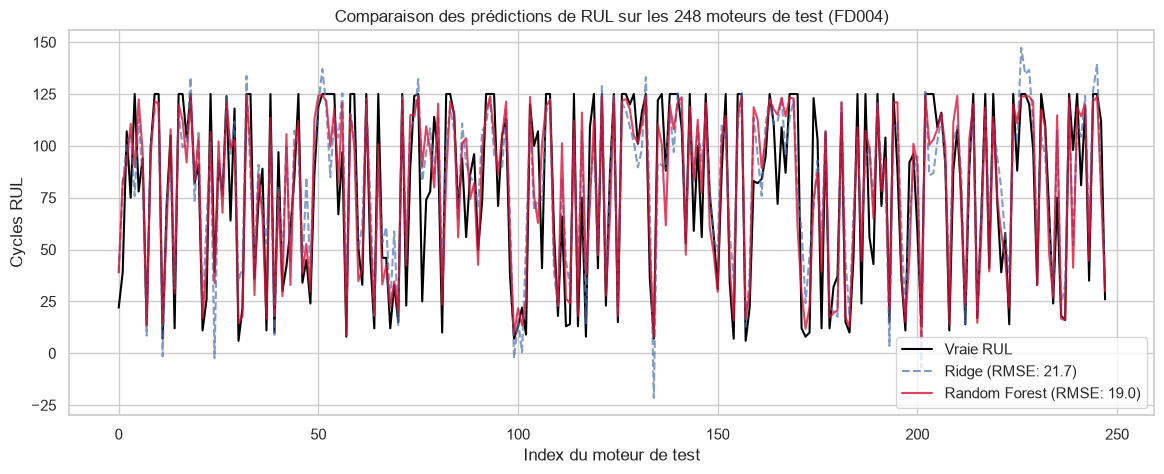

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(y_test, label="Vraie RUL", color="black", lw=1.5)
plt.plot(
    y_pred_ridge,
    label=f"Ridge (RMSE: {res_ridge['RMSE']:.1f})",
    alpha=0.7,
    ls="--",
)
plt.plot(
    y_pred_rf,
    label=f"Random Forest (RMSE: {res_rf['RMSE']:.1f})",
    alpha=0.8,
    color="crimson",
)
plt.title(
    "Comparaison des prédictions de RUL sur les 248 moteurs de test (FD004)"
)
plt.xlabel("Index du moteur de test")
plt.ylabel("Cycles RUL")
plt.legend()
plt.savefig(
    "../reports/figures/03_baselines_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()